In [12]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [13]:
!pip install -q ultralytics
!pip install -q pandas tqdm lxml

In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print("YOLO Loaded Successfully")

YOLO Loaded Successfully


In [15]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if files:
        print("Files:", files[:5])
    print("-"*50)

/kaggle/input
--------------------------------------------------
/kaggle/input/datasets
--------------------------------------------------
/kaggle/input/datasets/rkuo2000
--------------------------------------------------
/kaggle/input/datasets/rkuo2000/uecfood256
--------------------------------------------------
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256
Files: ['category.txt', 'README.txt']
--------------------------------------------------
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/248
Files: ['335042.jpg', '331307.jpg', '334649.jpg', '331256.jpg', '331747.jpg']
--------------------------------------------------
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/7
Files: ['623.jpg', '654.jpg', '14539.jpg', '646.jpg', '682.jpg']
--------------------------------------------------
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/135
Files: ['190648.jpg', '190988.jpg', '190994.jpg', '191358.jpg', '190798.jpg']
----------------------------------------------

In [16]:
import os

class_path = "/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/1"

print(os.listdir(class_path)[:20])


['11138.jpg', '13333.jpg', '11956.jpg', '14619.jpg', '45.jpg', '89.jpg', '20.jpg', '14510.jpg', '5158.jpg', '58.jpg', '14919.jpg', '6.jpg', '16675.jpg', '9135.jpg', '76.jpg', '11774.jpg', '9222.jpg', '15370.jpg', '14104.jpg', '71.jpg']


In [17]:
!find /kaggle/input/datasets/rkuo2000/uecfood256 -name "*.txt"

/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/248/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/7/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/135/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/47/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/183/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/17/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/81/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/19/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/199/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/121/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/192/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/22/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/2/bb_info.txt
/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/229/bb_info.txt
/kaggle/input/datasets/rkuo20

In [18]:
import pandas as pd

bb = pd.read_csv(
    "/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256/1/bb_info.txt",
    sep=" "
)

bb.head()

,img,x1,y1,x2,y2
0,1,0,143,370,486
1,2,20,208,582,559
2,3,2,110,243,410
3,4,0,237,286,536
4,5,8,28,761,585


In [19]:
import os

BASE = "/kaggle/working/food_yolo"

folders = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels",
    "test/images",
    "test/labels"
]

for folder in folders:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

print("Folders created")

Folders created


In [20]:
def convert_bbox(img_w, img_h, x1, y1, x2, y2):

    x_center = ((x1 + x2) / 2) / img_w
    y_center = ((y1 + y2) / 2) / img_h

    width = (x2 - x1) / img_w
    height = (y2 - y1) / img_h

    return x_center, y_center, width, height

In [21]:
import pandas as pd
import os

ROOT = "/kaggle/input/datasets/rkuo2000/uecfood256/UECFOOD256"

samples = []

for cls in range(1, 257):

    class_dir = os.path.join(ROOT, str(cls))

    bb_file = os.path.join(class_dir, "bb_info.txt")

    if not os.path.exists(bb_file):
        continue

    df = pd.read_csv(bb_file, sep=" ")

    for _, row in df.iterrows():

        img_name = f"{int(row['img'])}.jpg"

        img_path = os.path.join(class_dir, img_name)

        if os.path.exists(img_path):

            samples.append({
                "img_path": img_path,
                "class_id": cls - 1,
                "x1": row["x1"],
                "y1": row["y1"],
                "x2": row["x2"],
                "y2": row["y2"]
            })

print("Total Samples:", len(samples))

Total Samples: 31645


In [22]:
import random

random.shuffle(samples)

n = len(samples)

train_end = int(0.7*n)
valid_end = int(0.85*n)

train_data = samples[:train_end]
valid_data = samples[train_end:valid_end]
test_data = samples[valid_end:]

print("Train:", len(train_data))
print("Valid:", len(valid_data))
print("Test :", len(test_data))

Train: 22151
Valid: 4747
Test : 4747


In [23]:
import cv2
import shutil
from tqdm import tqdm

def save_split(data, split):

    for idx, item in enumerate(tqdm(data)):

        img = cv2.imread(item["img_path"])

        if img is None:
            continue

        h, w = img.shape[:2]

        xc, yc, bw, bh = convert_bbox(
            w, h,
            item["x1"],
            item["y1"],
            item["x2"],
            item["y2"]
        )

        img_dest = f"{BASE}/{split}/images/{idx}.jpg"
        label_dest = f"{BASE}/{split}/labels/{idx}.txt"

        shutil.copy(item["img_path"], img_dest)

        with open(label_dest, "w") as f:
            f.write(
                f"{item['class_id']} {xc} {yc} {bw} {bh}"
            )

In [24]:
save_split(train_data, "train")
save_split(valid_data, "valid")
save_split(test_data, "test")

100%|██████████| 4747/4747 [00:48<00:00, 98.81it/s] 


In [25]:
yaml_text = f"""
path: {BASE}

train: train/images
val: valid/images
test: test/images

names:
"""

for i in range(256):
    yaml_text += f"\n  {i}: food_{i}"

with open("food.yaml","w") as f:
    f.write(yaml_text)

print(yaml_text[:500])


path: /kaggle/working/food_yolo

train: train/images
val: valid/images
test: test/images

names:

  0: food_0
  1: food_1
  2: food_2
  3: food_3
  4: food_4
  5: food_5
  6: food_6
  7: food_7
  8: food_8
  9: food_9
  10: food_10
  11: food_11
  12: food_12
  13: food_13
  14: food_14
  15: food_15
  16: food_16
  17: food_17
  18: food_18
  19: food_19
  20: food_20
  21: food_21
  22: food_22
  23: food_23
  24: food_24
  25: food_25
  26: food_26
  27: food_27
  28: food_28
  29: food_29
 


In [26]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [27]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/kaggle/working/food.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    patience=5
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/food.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspect

In [30]:
from ultralytics import YOLO
best_model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

In [ ]:
best_model.info()

In [31]:
metrics = best_model.val(data="/kaggle/working/food.yaml")

print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)
print("mAP50     :", metrics.box.map50)
print("mAP50-95  :", metrics.box.map)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 8,237,840 parameters, 0 gradients, 46.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2597.7±1172.8 MB/s, size: 162.1 KB)
val: Scanning /kaggle/working/food_yolo/valid/labels.cache... 4747 images, 0 backgrounds, 16 corrupt: 100% ━━━━━━━━━━━━ 4747/4747 1.4Git/s 0.0s
val: /kaggle/working/food_yolo/valid/images/11.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.2133334]
val: /kaggle/working/food_yolo/valid/images/121.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.1910112]
val: /kaggle/working/food_yolo/valid/images/1427.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.1123595]
val: /kaggle/working/food_yolo/valid/images/1755.jpg: corrupt JPEG restored and saved
val: /kaggle/working/food_yolo/valid/images/1772.jpg: ignoring corrupt image/label: non-normalized or o

In [33]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

In [45]:
import random
from glob import glob

imgs = glob("/kaggle/working/food_yolo/valid/images/*.jpg")
print(random.choice(imgs))

/kaggle/working/food_yolo/valid/images/2652.jpg


In [47]:
import random
from glob import glob

imgs = glob("/kaggle/working/food_yolo/valid/images/*.jpg")

for i in range(10):
    img = random.choice(imgs)
    results = best_model.predict(
        source=img,
        conf=0.25,
        verbose=False
    )

    n = len(results[0].boxes)
    print(f"{img} -> {n} detections")

/kaggle/working/food_yolo/valid/images/39.jpg -> 1 detections
/kaggle/working/food_yolo/valid/images/438.jpg -> 1 detections
/kaggle/working/food_yolo/valid/images/4431.jpg -> 1 detections
/kaggle/working/food_yolo/valid/images/2912.jpg -> 1 detections
/kaggle/working/food_yolo/valid/images/371.jpg -> 0 detections
/kaggle/working/food_yolo/valid/images/1185.jpg -> 1 detections
/kaggle/working/food_yolo/valid/images/3659.jpg -> 3 detections
/kaggle/working/food_yolo/valid/images/654.jpg -> 1 detections
/kaggle/working/food_yolo/valid/images/1079.jpg -> 1 detections
/kaggle/working/food_yolo/valid/images/4042.jpg -> 1 detections


In [52]:
results = best_model.predict(
    source="/kaggle/working/food_yolo/valid/images/1185.jpg",
    conf=0.25,
    save=True
)

Results saved to /kaggle/working/runs/detect/predict


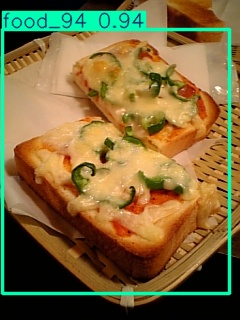

In [53]:
from PIL import Image
from IPython.display import display

display(Image.open("/kaggle/working/runs/detect/predict/1185.jpg"))

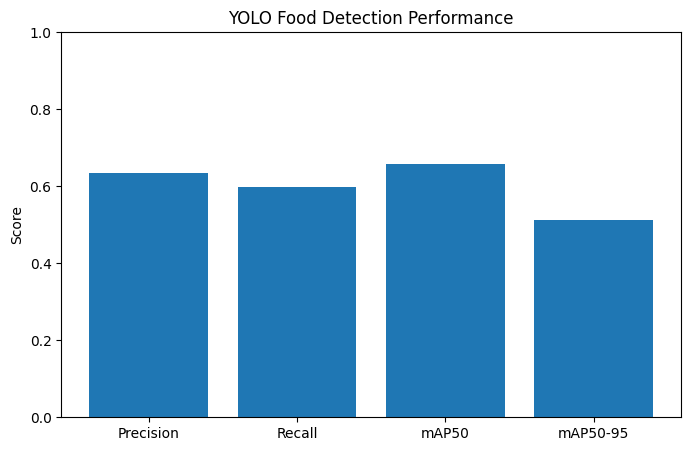

In [55]:
import matplotlib.pyplot as plt

metrics = {
    "Precision": 0.634,
    "Recall": 0.597,
    "mAP50": 0.658,
    "mAP50-95": 0.513
}

plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Score")
plt.ylim(0,1)
plt.title("YOLO Food Detection Performance")
plt.show()

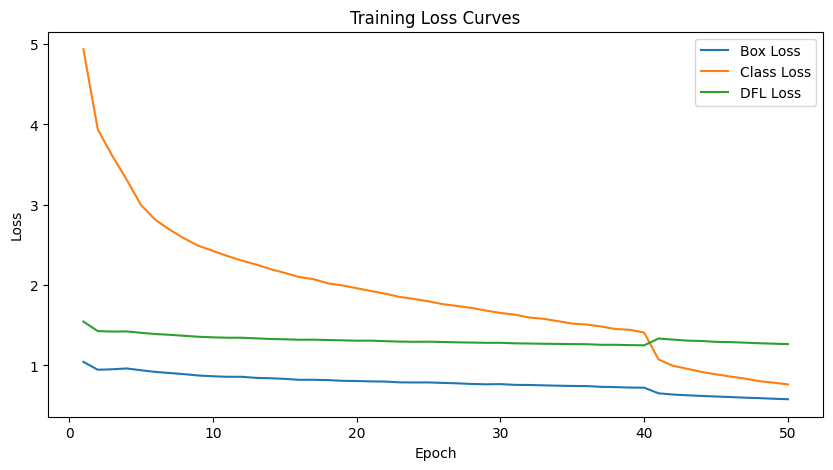

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")

plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train/box_loss'], label='Box Loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='Class Loss')
plt.plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.show()

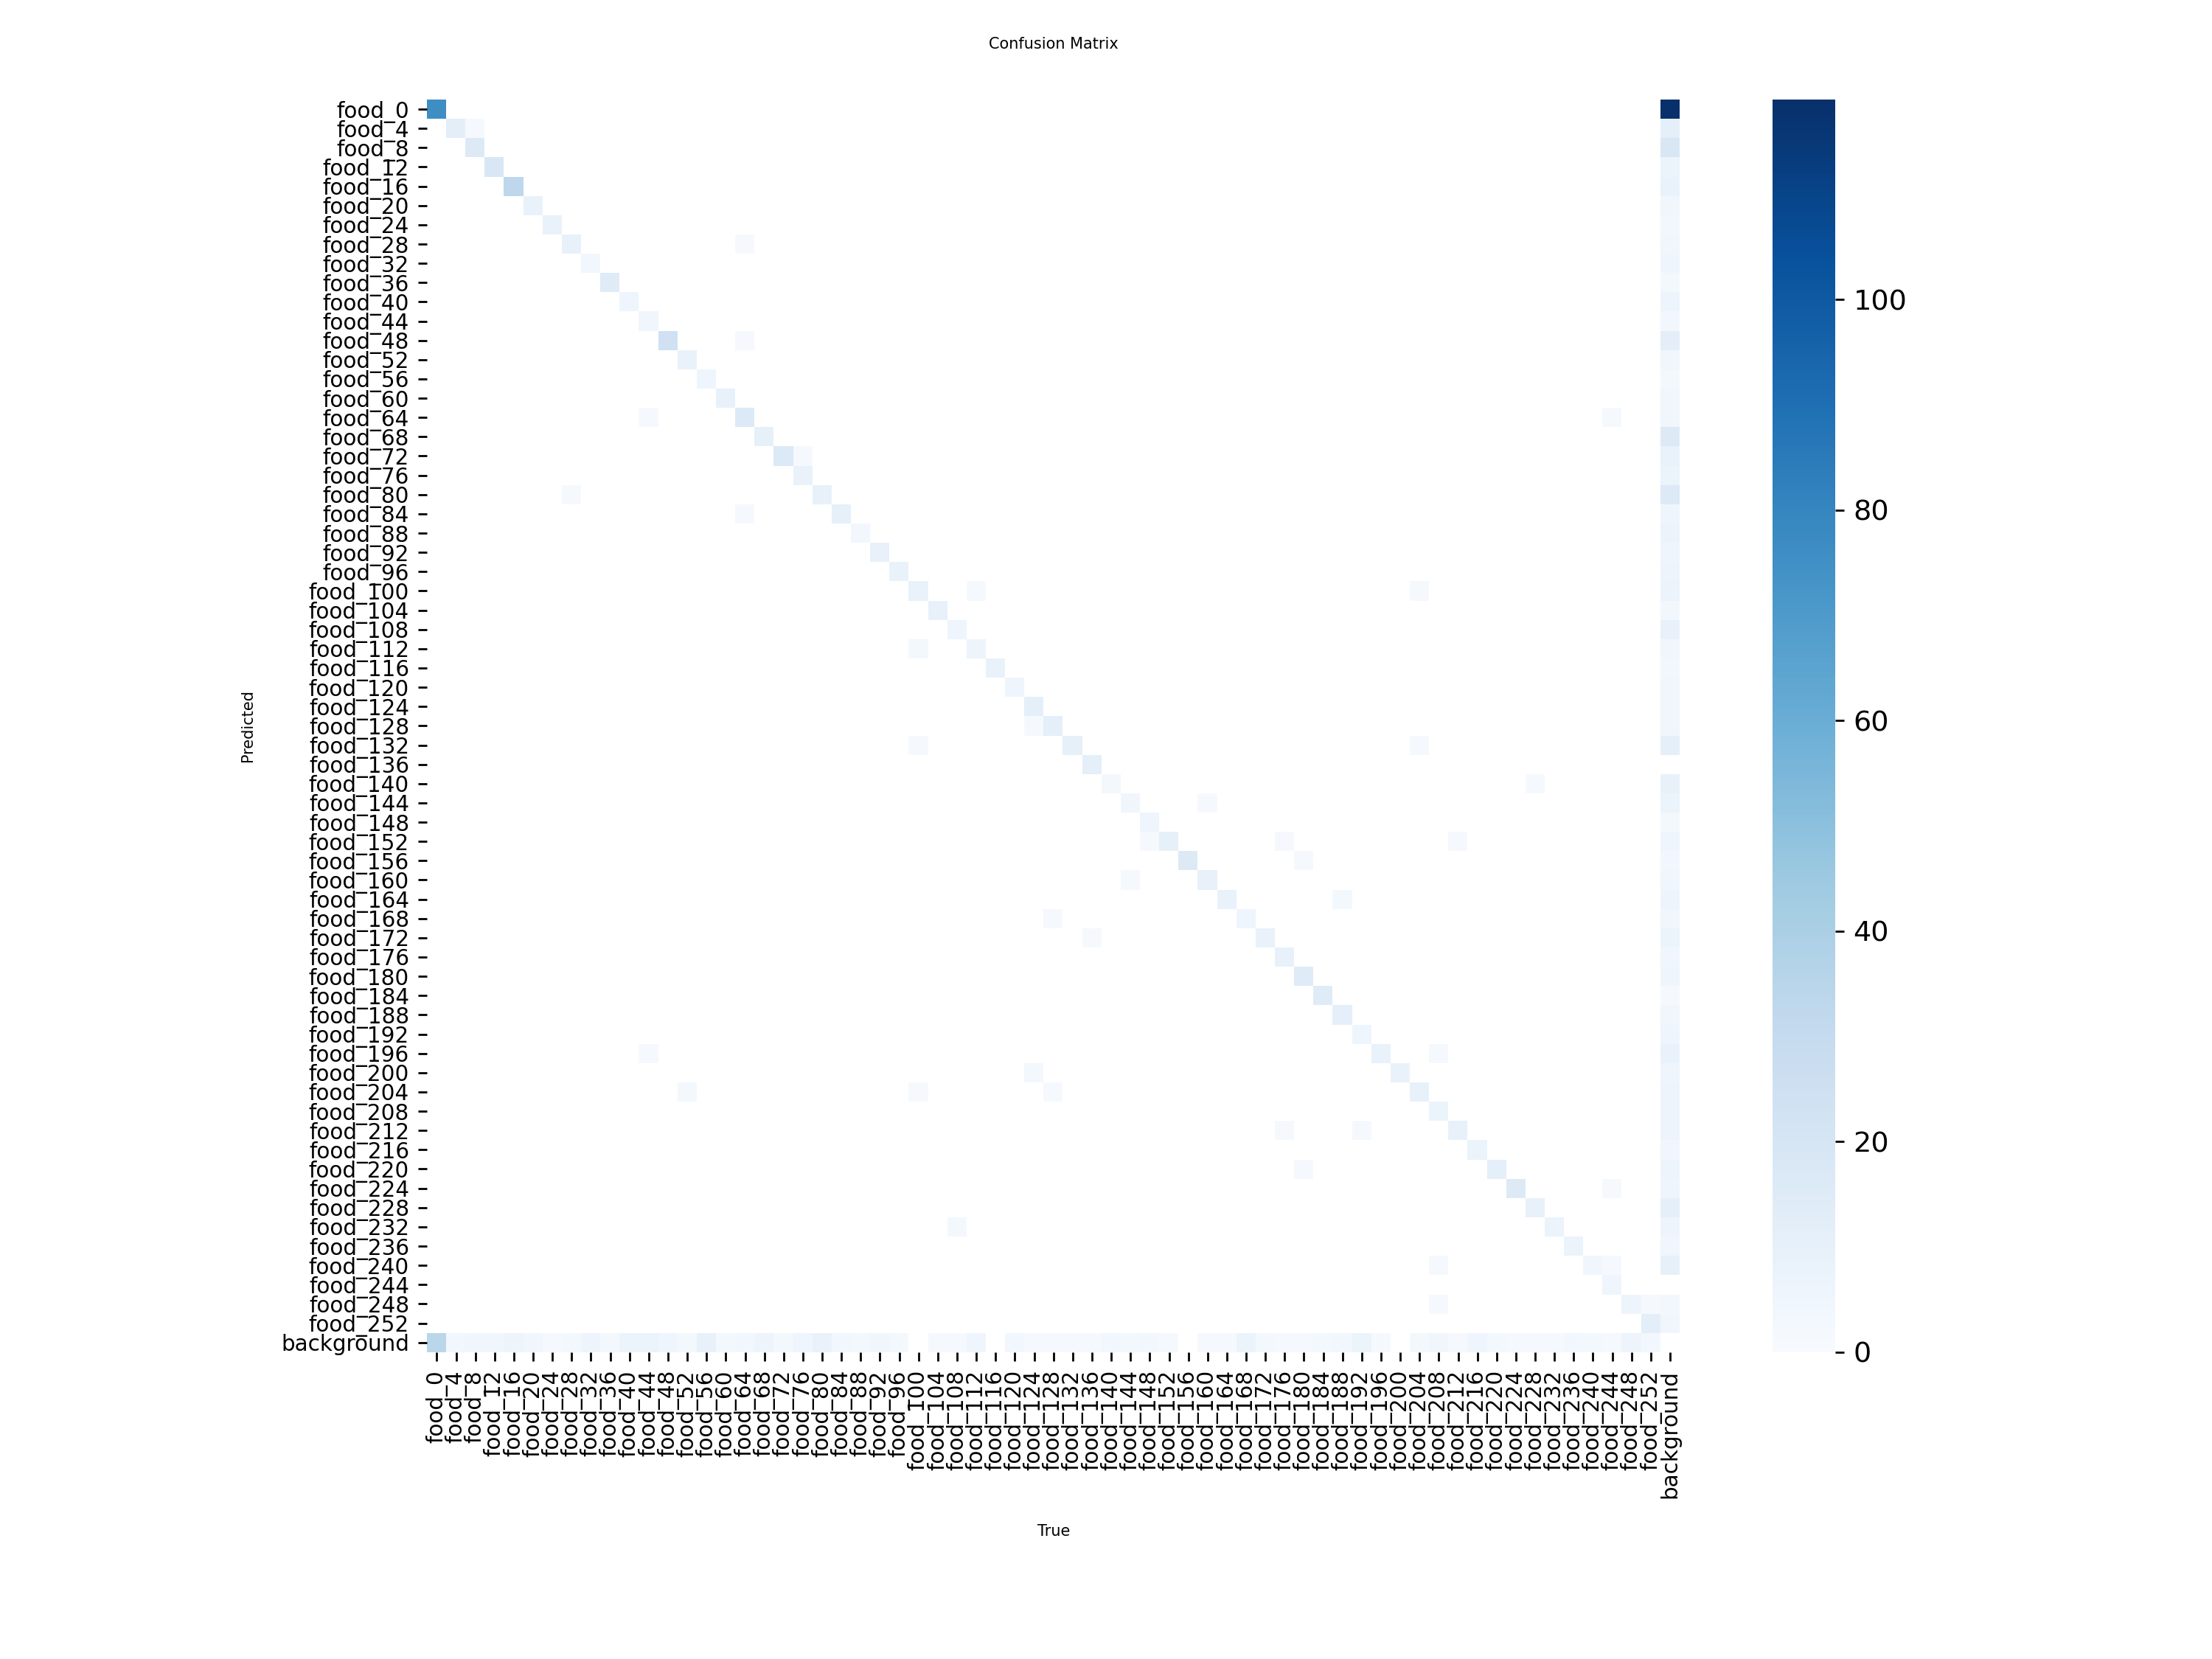

In [57]:
from PIL import Image
from IPython.display import display

display(Image.open("/kaggle/working/runs/detect/train/confusion_matrix.png"))

In [58]:
import os

for root, dirs, files in os.walk("/kaggle/working/runs"):
    for file in files:
        if file == "best.pt":
            print(os.path.join(root, file))

/kaggle/working/runs/detect/train/weights/best.pt
